# Problema de regresie

## 1. Definirea problemei

În această parte a proiectului este abordată o problemă de regresie, folosind dataset-ul California Housing. Scopul este construirea unor modele de machine learning capabile să prezică valoarea mediană a locuințelor din diferite zone ale Californiei, pe baza unor caracteristici socio-economice și geografice.

Variabila țintă este `MedHouseVal`, care reprezintă valoarea mediană a locuințelor, exprimată în sute de mii de dolari.

Caracteristicile de intrare includ informații precum venitul median al zonei, vechimea locuințelor, numărul mediu de camere, numărul mediu de dormitoare, populația, gradul mediu de ocupare, latitudinea și longitudinea.

Am ales acest dataset deoarece este o problemă clasică de regresie, potrivită pentru compararea mai multor algoritmi de machine learning. În plus, dataset-ul permite analizarea relației dintre caracteristicile socio-economice și valoarea locuințelor.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.data import load_regression_data
from src.models import get_regression_models
from src.evaluation import (
    evaluate_regression_model,
    regression_results_to_dataframe
)

In [2]:
df, X, y = load_regression_data()

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Dimensiune dataset:", df.shape)

df.info()

Dimensiune dataset: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## 2. Analiza exploratorie a datelor

În această secțiune analizăm structura dataset-ului, valorile lipsă, distribuția variabilei țintă și relațiile dintre variabile. Pentru o problemă de regresie, este important să observăm atât distribuția valorii prezise, cât și corelațiile dintre caracteristici și target.

In [6]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

Nu au fost identificate valori lipsă în dataset. Prin urmare, nu este necesară aplicarea unor metode de imputare.

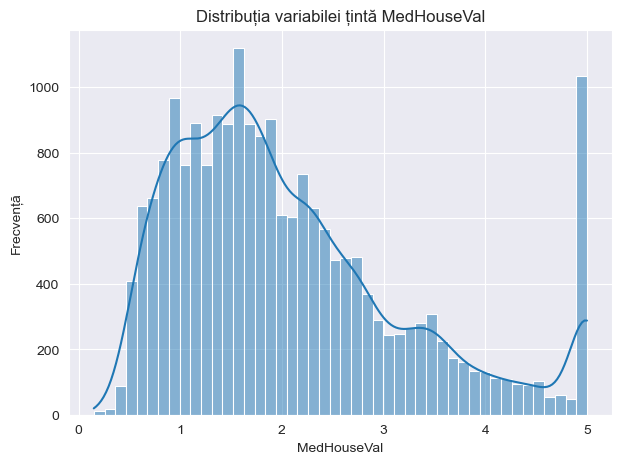

In [7]:
plt.figure(figsize=(7, 5))
sns.histplot(df["MedHouseVal"], kde=True)
plt.title("Distribuția variabilei țintă MedHouseVal")
plt.xlabel("MedHouseVal")
plt.ylabel("Frecvență")
plt.show()

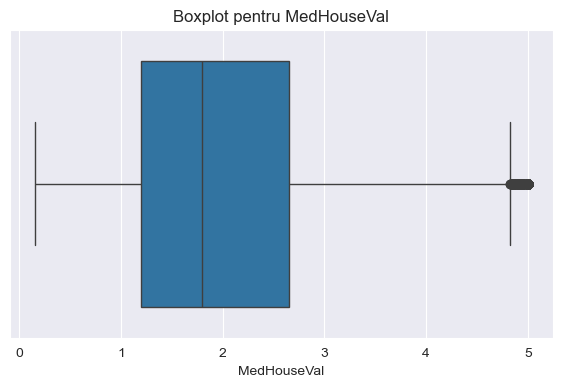

In [8]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=df["MedHouseVal"])
plt.title("Boxplot pentru MedHouseVal")
plt.xlabel("MedHouseVal")
plt.show()

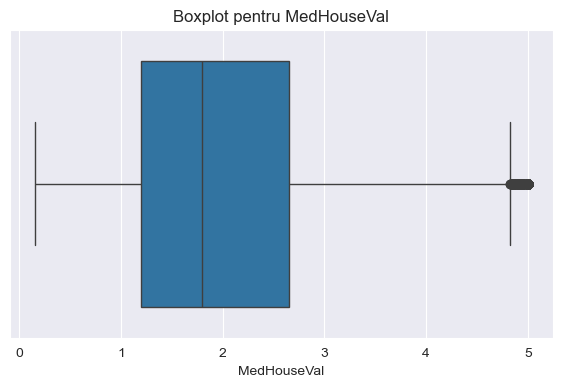

In [9]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=df["MedHouseVal"])
plt.title("Boxplot pentru MedHouseVal")
plt.xlabel("MedHouseVal")
plt.show()

In [10]:
target_correlations = (
    df.corr(numeric_only=True)["MedHouseVal"]
    .sort_values(key=abs, ascending=False)
)

target_correlations

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
Latitude      -0.144160
HouseAge       0.105623
AveBedrms     -0.046701
Longitude     -0.045967
Population    -0.024650
AveOccup      -0.023737
Name: MedHouseVal, dtype: float64

Distribuția variabilei țintă oferă o imagine asupra valorilor pe care modelul trebuie să le prezică. Matricea de corelație arată relațiile liniare dintre variabile, iar corelațiile cu `MedHouseVal` oferă o primă indicație asupra caracteristicilor care pot influența valoarea locuințelor.

Totuși, corelația liniară nu surprinde toate relațiile posibile dintre variabile, iar modelele de machine learning pot identifica și relații neliniare sau interacțiuni între caracteristici.

Nu au fost identificate valori lipsă în dataset. Prin urmare, nu este necesară aplicarea unor metode de imputare.

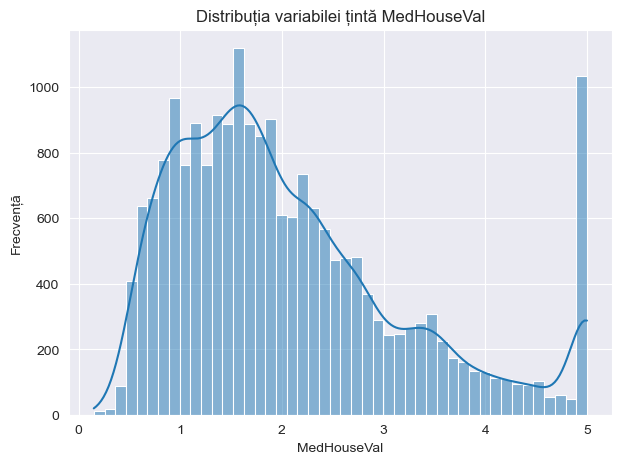

In [12]:
plt.figure(figsize=(7, 5))
sns.histplot(df["MedHouseVal"], kde=True)
plt.title("Distribuția variabilei țintă MedHouseVal")
plt.xlabel("MedHouseVal")
plt.ylabel("Frecvență")
plt.show()

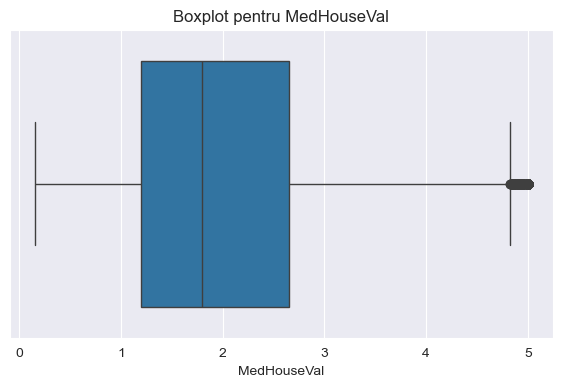

In [13]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=df["MedHouseVal"])
plt.title("Boxplot pentru MedHouseVal")
plt.xlabel("MedHouseVal")
plt.show()

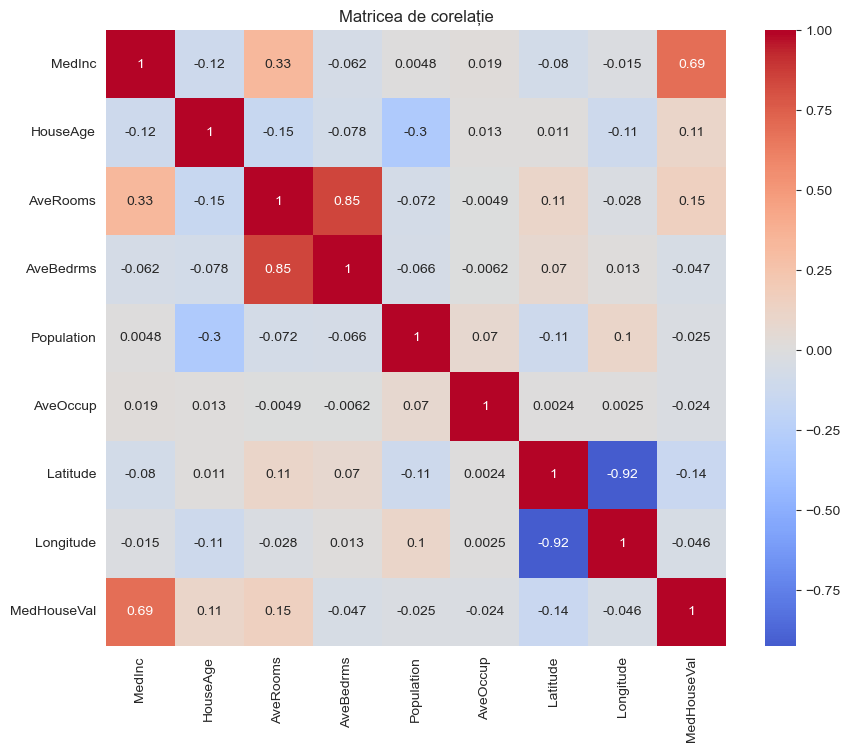

In [14]:
plt.figure(figsize=(10, 8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matricea de corelație")
plt.show()

In [15]:
target_correlations = (
    df.corr(numeric_only=True)["MedHouseVal"]
    .sort_values(key=abs, ascending=False)
)

target_correlations

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
Latitude      -0.144160
HouseAge       0.105623
AveBedrms     -0.046701
Longitude     -0.045967
Population    -0.024650
AveOccup      -0.023737
Name: MedHouseVal, dtype: float64

Matricea de corelație arată relațiile liniare dintre variabilele numerice. În cazul regresiei, este important să observăm ce caracteristici au o legătură mai puternică cu variabila țintă `MedHouseVal`.

Corelațiile cu variabila țintă oferă o primă indicație asupra caracteristicilor relevante. Totuși, această analiză nu este suficientă pentru a determina complet importanța variabilelor, deoarece modelele de machine learning pot surprinde și relații neliniare.

## 3. Pregătirea datelor pentru antrenare

Dataset-ul este împărțit în date de antrenare și date de testare. Conform cerinței proiectului, folosim 75% dintre observații pentru antrenare și 25% pentru testare și validare.

Pentru modelele sensibile la scara variabilelor, precum Support Vector Regressor și K-Nearest Neighbor Regressor, folosim `StandardScaler` într-un `Pipeline`.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (15480, 8)
X_test: (5160, 8)
y_train: (15480,)
y_test: (5160,)


## 4. Antrenarea și compararea modelelor de bază

În această etapă sunt antrenate modelele de regresie propuse în cerința proiectului, folosind valorile implicite ale hiperparametrilor. Pentru fiecare model calculăm metricile MSE, MAE, RMSE și R².

In [18]:
regression_models = get_regression_models(random_state=42)

regression_models.keys()

dict_keys(['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor', 'Support Vector Regressor', 'K-Nearest Neighbor Regressor', 'Gaussian Process Regressor', 'XGBoost Regressor', 'CatBoost Regressor', 'Explainable Boosting Regressor'])

In [19]:
regression_results = {}
trained_regression_models = {}

models_that_need_scaling = [
    "Support Vector Regressor",
    "K-Nearest Neighbor Regressor",
    "Gaussian Process Regressor"
]

for model_name, model in regression_models.items():
    print(f"Training: {model_name}")

    if model_name in models_that_need_scaling:
        final_model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    else:
        final_model = model

    final_model.fit(X_train, y_train)

    metrics = evaluate_regression_model(
        final_model,
        X_test,
        y_test
    )

    regression_results[model_name] = metrics
    trained_regression_models[model_name] = final_model

Training: Linear Regression
Training: Decision Tree Regressor
Training: Random Forest Regressor
Training: Support Vector Regressor
Training: K-Nearest Neighbor Regressor
Training: Gaussian Process Regressor
Training: XGBoost Regressor
Training: CatBoost Regressor
Training: Explainable Boosting Regressor


In [20]:
regression_results_df = regression_results_to_dataframe(
    regression_results
)

regression_results_df

,Model,MSE,MAE,RMSE,R2
0,CatBoost Regressor,0.199053,0.294413,0.446154,0.849569
1,Explainable Boosting Regressor,0.211217,0.309770,0.459583,0.840376
2,XGBoost Regressor,0.216141,0.305435,0.464910,0.836655
3,Random Forest Regressor,0.254236,0.329097,0.504218,0.807866
4,Support Vector Regressor,0.351007,0.396428,0.592458,0.734733
5,K-Nearest Neighbor Regressor,0.431691,0.446074,0.657032,0.673757
6,Decision Tree Regressor,0.528522,0.467076,0.726995,0.600578
7,Linear Regression,0.541129,0.529696,0.735615,0.591051
8,Gaussian Process Regressor,2478.455142,14.792096,49.784085,-1872.051111


In [21]:
top_5_regression_models = regression_results_df.head(5)

top_5_regression_models

,Model,MSE,MAE,RMSE,R2
0,CatBoost Regressor,0.199053,0.294413,0.446154,0.849569
1,Explainable Boosting Regressor,0.211217,0.309770,0.459583,0.840376
2,XGBoost Regressor,0.216141,0.305435,0.464910,0.836655
3,Random Forest Regressor,0.254236,0.329097,0.504218,0.807866
4,Support Vector Regressor,0.351007,0.396428,0.592458,0.734733


In [22]:
top_5_regression_model_names = top_5_regression_models["Model"].tolist()

top_5_regression_model_names

['CatBoost Regressor',
 'Explainable Boosting Regressor',
 'XGBoost Regressor',
 'Random Forest Regressor',
 'Support Vector Regressor']

## 5. Ajustarea hiperparametrilor

În această etapă sunt ajustați hiperparametrii pentru primele 5 modele de regresie. Scopul este îmbunătățirea performanței modelelor și alegerea celui mai bun algoritm pe baza metricilor specifice regresiei: MSE, MAE, RMSE și R².

Pentru Support Vector Regressor se folosește scalarea datelor prin `StandardScaler`, deoarece modelul este sensibil la scara caracteristicilor. Modelele bazate pe arbori sau boosting sunt antrenate direct.

In [24]:
from sklearn.model_selection import GridSearchCV
from itertools import product
from catboost import CatBoostRegressor

In [25]:
regression_tuning_configs = {
    "Support Vector Regressor": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", regression_models["Support Vector Regressor"])
        ]),
        "params": {
            "model__C": [1, 10, 100],
            "model__epsilon": [0.01, 0.1, 0.2],
            "model__kernel": ["rbf"],
            "model__gamma": ["scale", "auto"]
        }
    },

    "Random Forest Regressor": {
        "model": regression_models["Random Forest Regressor"],
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2]
        }
    },

    "XGBoost Regressor": {
        "model": regression_models["XGBoost Regressor"],
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.8, 1.0]
        }
    },

    "CatBoost Regressor": {
        "model": regression_models["CatBoost Regressor"],
        "params": {
            "depth": [4, 6, 8],
            "learning_rate": [0.03, 0.05, 0.1],
            "iterations": [200, 400]
        }
    },

    "Explainable Boosting Regressor": {
        "model": regression_models["Explainable Boosting Regressor"],
        "params": {
            "max_bins": [128, 256],
            "interactions": [0, 5, 10],
            "learning_rate": [0.01, 0.05]
        }
    }
}

In [26]:
X_train_tuning = X_train.sample(n=min(3000, len(X_train)), random_state=42)
y_train_tuning = y_train.loc[X_train_tuning.index]

X_train_tuning.shape, y_train_tuning.shape

((3000, 8), (3000,))

In [27]:
regression_tuning_configs = {
    "Support Vector Regressor": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", regression_models["Support Vector Regressor"])
        ]),
        "params": {
            "model__C": [10],
            "model__epsilon": [0.1],
            "model__gamma": ["scale"]
        }
    },

    "Random Forest Regressor": {
        "model": regression_models["Random Forest Regressor"],
        "params": {
            "n_estimators": [100],
            "max_depth": [20],
            "min_samples_leaf": [1]
        }
    },

    "XGBoost Regressor": {
        "model": regression_models["XGBoost Regressor"],
        "params": {
            "n_estimators": [100],
            "max_depth": [5],
            "learning_rate": [0.1],
            "subsample": [0.8]
        }
    },

    "CatBoost Regressor": {
        "model": regression_models["CatBoost Regressor"],
        "params": {
            "depth": [6],
            "learning_rate": [0.1],
            "iterations": [200]
        }
    },

    "Explainable Boosting Regressor": {
        "model": regression_models["Explainable Boosting Regressor"],
        "params": {
            "interactions": [5],
            "learning_rate": [0.05]
        }
    }
}

In [28]:
tuned_regression_results = {}
tuned_regression_models = {}
best_regression_params_by_model = {}

for model_name in top_5_regression_model_names:
    print(f"Tuning rapid: {model_name}")

    config = regression_tuning_configs[model_name]

    if model_name == "CatBoost Regressor":
        params = {
            "depth": 6,
            "learning_rate": 0.1,
            "iterations": 200
        }

        final_model = CatBoostRegressor(
            **params,
            verbose=0,
            random_state=42
        )

        final_model.fit(X_train, y_train)

        metrics = evaluate_regression_model(final_model, X_test, y_test)

        tuned_regression_results[model_name] = metrics
        tuned_regression_models[model_name] = final_model
        best_regression_params_by_model[model_name] = params

        print("Params:", params)
        print("Test R2:", metrics["R2"])
        print()

    else:
        grid_search = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            scoring="r2",
            cv=2,
            n_jobs=-1
        )

        grid_search.fit(X_train_tuning, y_train_tuning)

        final_model = grid_search.best_estimator_
        final_model.fit(X_train, y_train)

        metrics = evaluate_regression_model(final_model, X_test, y_test)

        tuned_regression_results[model_name] = metrics
        tuned_regression_models[model_name] = final_model
        best_regression_params_by_model[model_name] = grid_search.best_params_

        print("Best params:", grid_search.best_params_)
        print("Best CV R2:", grid_search.best_score_)
        print("Test R2:", metrics["R2"])
        print()

Tuning rapid: CatBoost Regressor
Params: {'depth': 6, 'learning_rate': 0.1, 'iterations': 200}
Test R2: 0.8268216543785721

Tuning rapid: Explainable Boosting Regressor
Best params: {'interactions': 5, 'learning_rate': 0.05}
Best CV R2: 0.7804635461375864
Test R2: 0.828748287484754

Tuning rapid: XGBoost Regressor
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best CV R2: 0.7766228094997165
Test R2: 0.8219162320738589

Tuning rapid: Random Forest Regressor
Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV R2: 0.730656882696185
Test R2: 0.8078087576709643

Tuning rapid: Support Vector Regressor
Best params: {'model__C': 10, 'model__epsilon': 0.1, 'model__gamma': 'scale'}
Best CV R2: 0.7246226336744958
Test R2: 0.7579142233057643



In [29]:
tuned_regression_results_df = regression_results_to_dataframe(
    tuned_regression_results
)

tuned_regression_results_df

,Model,MSE,MAE,RMSE,R2
0,Explainable Boosting Regressor,0.226603,0.319686,0.476029,0.828748
1,CatBoost Regressor,0.229153,0.323172,0.478699,0.826822
2,XGBoost Regressor,0.235644,0.327782,0.485431,0.821916
3,Random Forest Regressor,0.254311,0.328763,0.504293,0.807809
4,Support Vector Regressor,0.320332,0.376235,0.565979,0.757914


In [30]:
best_regression_model_name = tuned_regression_results_df.iloc[0]["Model"]
best_regression_model = tuned_regression_models[best_regression_model_name]

best_regression_model_name

'Explainable Boosting Regressor'

In [31]:
best_regression_params_by_model

{'CatBoost Regressor': {'depth': 6, 'learning_rate': 0.1, 'iterations': 200},
 'Explainable Boosting Regressor': {'interactions': 5, 'learning_rate': 0.05},
 'XGBoost Regressor': {'learning_rate': 0.1,
  'max_depth': 5,
  'n_estimators': 100,
  'subsample': 0.8},
 'Random Forest Regressor': {'max_depth': 20,
  'min_samples_leaf': 1,
  'n_estimators': 100},
 'Support Vector Regressor': {'model__C': 10,
  'model__epsilon': 0.1,
  'model__gamma': 'scale'}}

### Interpretarea rezultatelor după ajustarea hiperparametrilor

După ajustarea hiperparametrilor, modelele de regresie din top 5 au fost reevaluate pe setul de testare. Performanța a fost analizată folosind metricile MSE, MAE, RMSE și R².

Metricile de eroare, precum MSE, MAE și RMSE, indică diferența dintre valorile reale și valorile prezise, iar un scor mai mic este mai bun. În schimb, R² exprimă proporția variației explicate de model, iar o valoare mai mare indică o performanță mai bună.

Cel mai bun model de regresie a fost selectat pe baza scorului R², dar interpretarea finală trebuie să țină cont și de valorile erorilor.

## 6. Curbele de învățare

Curbele de învățare sunt folosite pentru a observa cum se modifică performanța modelelor pe măsură ce crește dimensiunea setului de antrenare. În regresie, acestea ajută la identificarea situațiilor de overfitting sau underfitting, analizând diferența dintre scorul de antrenare și scorul de validare.



In [32]:
from sklearn.model_selection import learning_curve

In [33]:
X_lc = X.sample(n=min(3000, len(X)), random_state=42)
y_lc = y.loc[X_lc.index]

X_lc.shape, y_lc.shape

((3000, 8), (3000,))

In [34]:
def plot_regression_learning_curve_fast(model, X, y, model_name):
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=[0.2, 0.5, 1.0],
        cv=2,
        scoring="r2",
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    plt.figure(figsize=(7, 5))

    plt.plot(
        train_sizes,
        train_mean,
        marker="o",
        label="Scor antrenare"
    )

    plt.plot(
        train_sizes,
        validation_mean,
        marker="o",
        label="Scor validare"
    )

    plt.title(f"Curba de învățare - {model_name}")
    plt.xlabel("Număr de exemple de antrenare")
    plt.ylabel("R²")
    plt.legend()
    plt.grid(True)
    plt.show()

CatBoost Regressor este sărit pentru learning curve deoarece durează prea mult sau are incompatibilități.
Explainable Boosting Regressor este sărit pentru learning curve deoarece durează prea mult sau are incompatibilități.


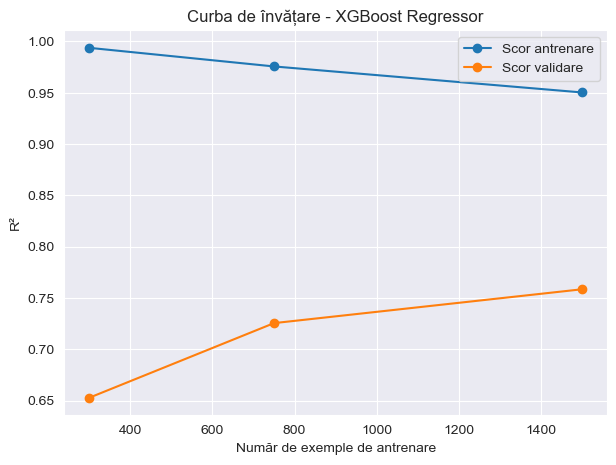

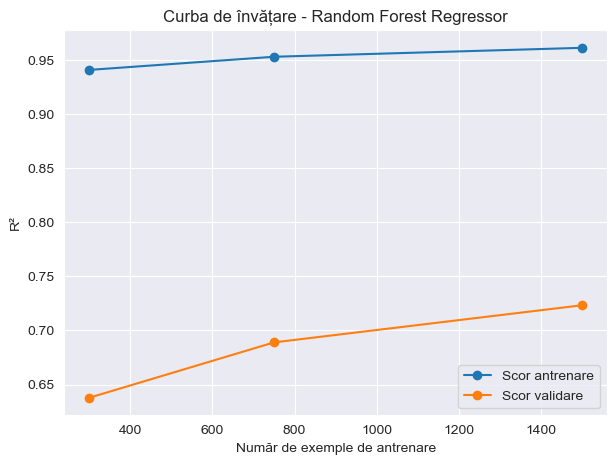

Support Vector Regressor este sărit pentru learning curve deoarece durează prea mult sau are incompatibilități.


In [35]:
slow_models = [
    "CatBoost Regressor",
    "Support Vector Regressor",
    "Explainable Boosting Regressor"
]

for model_name, model in tuned_regression_models.items():
    if model_name in slow_models:
        print(
            f"{model_name} este sărit pentru learning curve "
            "deoarece durează prea mult sau are incompatibilități."
        )
        continue

    plot_regression_learning_curve_fast(
        model=model,
        X=X_lc,
        y=y_lc,
        model_name=model_name
    )

Notă: Pentru unele modele de regresie, curbele de învățare au fost omise deoarece timpul de rulare este foarte mare pe dataset-ul complet sau există incompatibilități cu funcția `learning_curve` din scikit-learn. Au fost afișate curbele pentru modelele care rulează eficient, păstrând analiza comportamentului de învățare și generalizare.


### Interpretarea curbelor de învățare

Curbele de învățare permit compararea scorului obținut pe datele de antrenare cu scorul obținut pe datele de validare. În cazul regresiei, scorul folosit este R².

Dacă scorul de antrenare este semnificativ mai mare decât scorul de validare, modelul poate suferi de overfitting, adică învață prea bine particularitățile datelor de antrenare, dar generalizează mai slab pe date noi.

Dacă atât scorul de antrenare, cât și scorul de validare sunt scăzute, modelul poate suferi de underfitting, adică nu reușește să surprindă suficient de bine relațiile dintre variabile.

Modelele preferate sunt cele care obțin un scor R² ridicat și la care diferența dintre curba de antrenare și curba de validare este relativ mică.


## 7. Explicabilitatea modelelor folosind SHAP

În această etapă sunt analizate primele 3 modele de regresie perfecționate, folosind SHAP. Scopul este interpretarea modului în care caracteristicile de intrare influențează predicțiile modelelor.

SHAP permite analizarea importanței globale a caracteristicilor, dar și explicarea locală a unei predicții individuale. Astfel, putem observa ce variabile contribuie cel mai mult la valoarea prezisă de model și dacă acestea împing predicția în sus sau în jos.


In [36]:
top_3_regression_model_names = tuned_regression_results_df.head(3)["Model"].tolist()

top_3_regression_model_names

['Explainable Boosting Regressor', 'CatBoost Regressor', 'XGBoost Regressor']

In [37]:
import shap

shap.initjs()

In [38]:
X_shap = X_test.sample(n=min(300, len(X_test)), random_state=42)

X_shap.shape

(300, 8)

In [39]:
def run_regression_shap_analysis(model, model_name, X_sample):
    print(f"SHAP analysis pentru: {model_name}")

    explainer = shap.Explainer(model, X_sample)
    shap_values = explainer(X_sample)

    print("Bar plot - importanță globală")
    shap.plots.bar(shap_values, max_display=10)

    print("Beeswarm plot - distribuția impactului caracteristicilor")
    shap.plots.beeswarm(shap_values, max_display=10)

    print("Waterfall plot - explicație locală pentru prima predicție")
    shap.plots.waterfall(shap_values[0], max_display=10)

    return shap_values

In [41]:
model.predict

<bound method ExplainableBoostingRegressor.predict of ExplainableBoostingRegressor(interactions=5, learning_rate=0.05)>

In [42]:
def run_regression_shap_analysis(model, model_name, X_sample):
    print(f"SHAP analysis pentru: {model_name}")

    if model_name == "Explainable Boosting Regressor":
        explainer = shap.Explainer(model.predict, X_sample)
    else:
        explainer = shap.Explainer(model, X_sample)

    shap_values = explainer(X_sample)

    print("Bar plot - importanță globală")
    shap.plots.bar(shap_values, max_display=10)

    print("Beeswarm plot - distribuția impactului caracteristicilor")
    shap.plots.beeswarm(shap_values, max_display=10)

    print("Waterfall plot - explicație locală pentru prima predicție")
    shap.plots.waterfall(shap_values[0], max_display=10)

    return shap_values

SHAP analysis pentru: Explainable Boosting Regressor


ExactExplainer explainer: 301it [00:18, 16.17it/s]                          


Bar plot - importanță globală


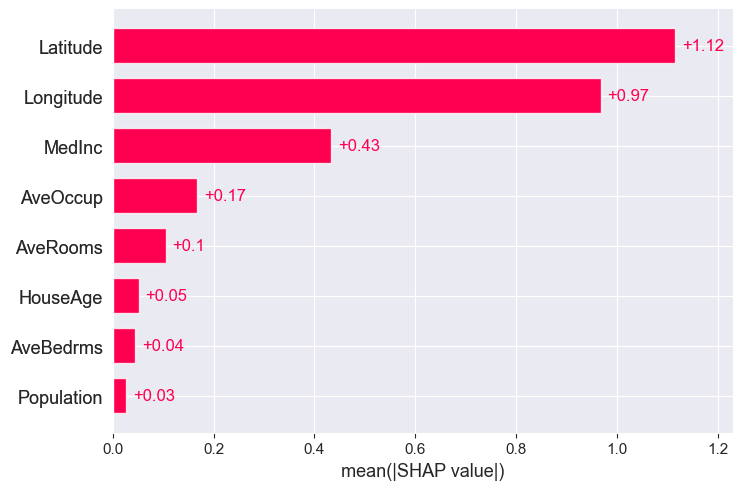

Beeswarm plot - distribuția impactului caracteristicilor


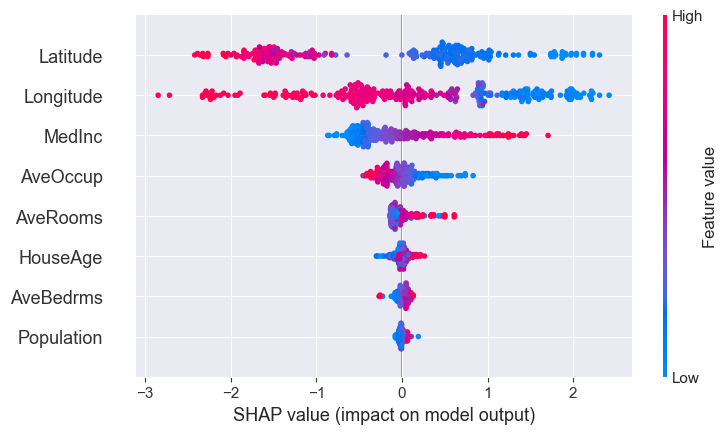

Waterfall plot - explicație locală pentru prima predicție


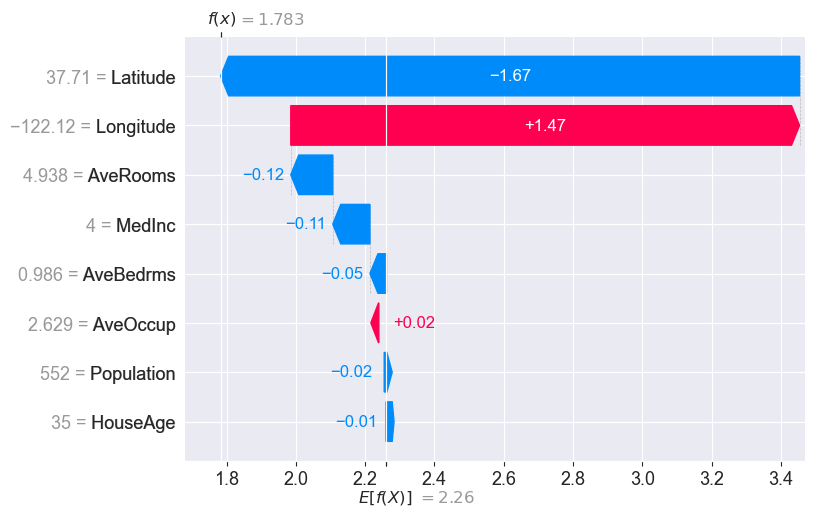

SHAP analysis pentru: CatBoost Regressor
Bar plot - importanță globală


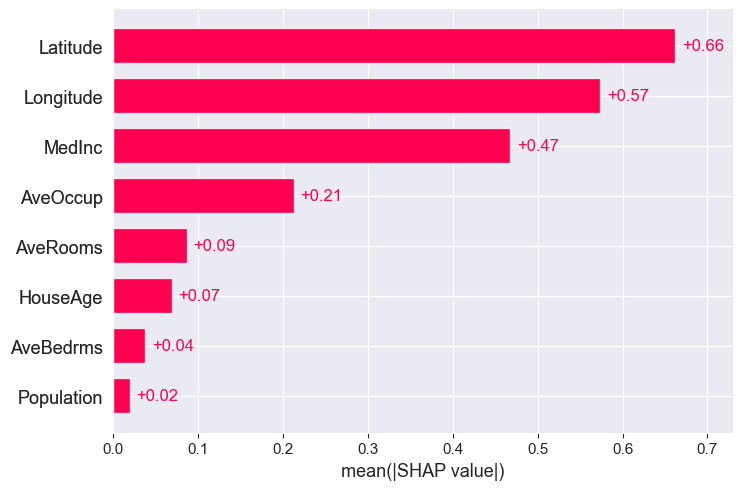

Beeswarm plot - distribuția impactului caracteristicilor


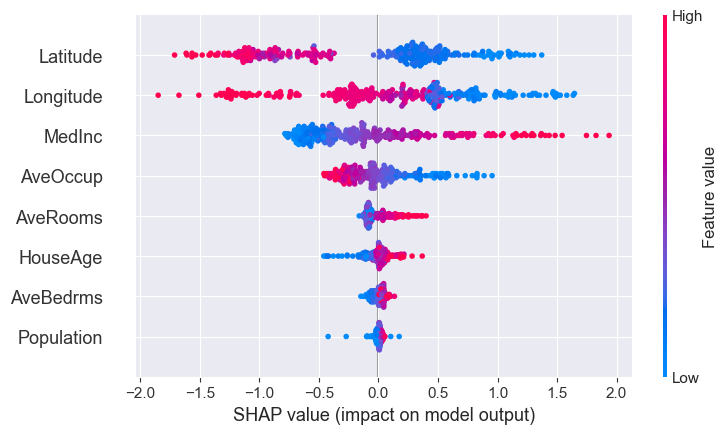

Waterfall plot - explicație locală pentru prima predicție


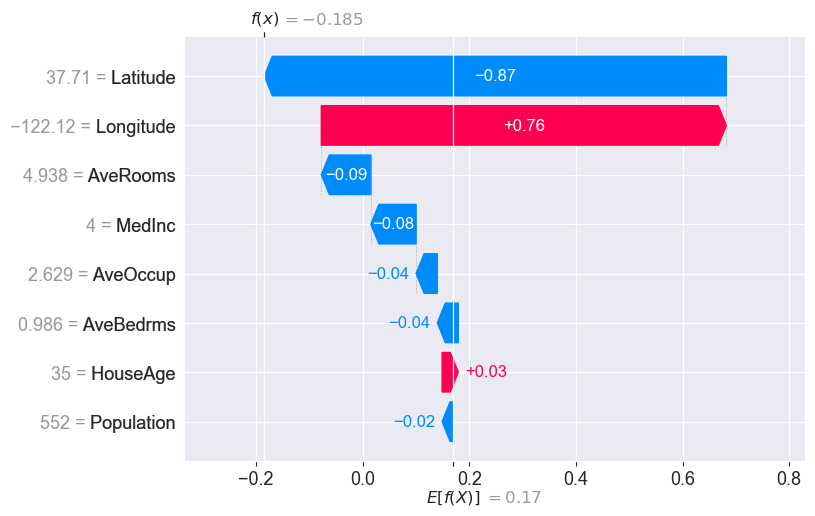

SHAP analysis pentru: XGBoost Regressor
Bar plot - importanță globală


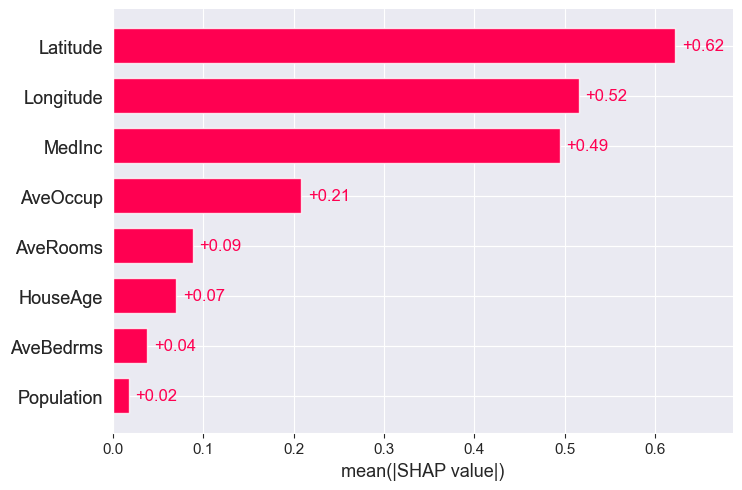

Beeswarm plot - distribuția impactului caracteristicilor


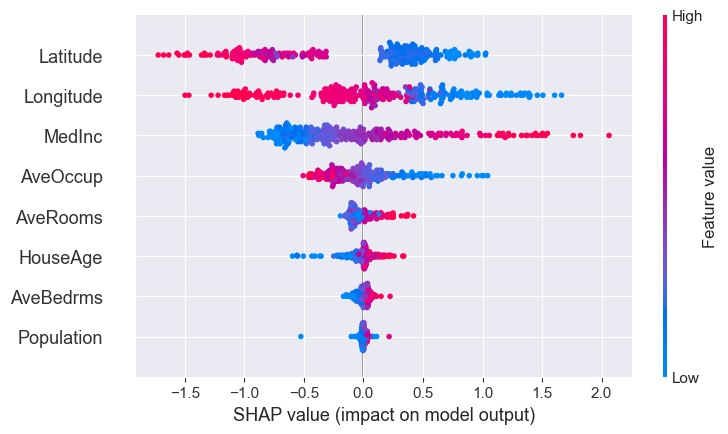

Waterfall plot - explicație locală pentru prima predicție


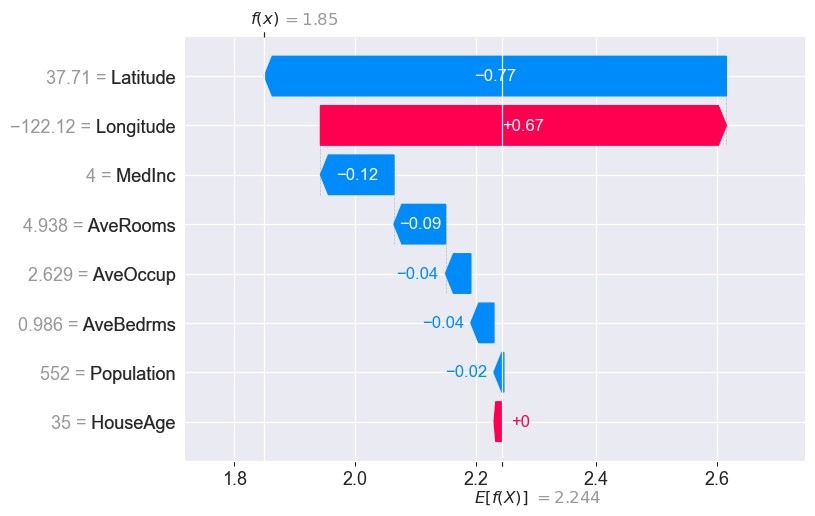

In [43]:
regression_shap_values = {}

models_skipped_for_shap = [
    "Support Vector Regressor"
]

for model_name in top_3_regression_model_names:
    if model_name in models_skipped_for_shap:
        print(f"{model_name} este sărit pentru SHAP deoarece KernelExplainer ar dura prea mult.")
        continue

    model = tuned_regression_models[model_name]

    shap_values = run_regression_shap_analysis(
        model=model,
        model_name=model_name,
        X_sample=X_shap
    )

    regression_shap_values[model_name] = shap_values

In [45]:
X_shap = X_test.sample(n=min(100, len(X_test)), random_state=42)

In [46]:
for model_name, shap_values in regression_shap_values.items():
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

    importance_df = pd.DataFrame({
        "Feature": X_shap.columns,
        "Mean Absolute SHAP": mean_abs_shap
    }).sort_values(by="Mean Absolute SHAP", ascending=False)

    print(f"\nTop 3 caracteristici pentru {model_name}:")
    display(importance_df.head(3))


Top 3 caracteristici pentru Explainable Boosting Regressor:


,Feature,Mean Absolute SHAP
6,Latitude,1.115466
7,Longitude,0.967583
0,MedInc,0.433142



Top 3 caracteristici pentru CatBoost Regressor:


,Feature,Mean Absolute SHAP
6,Latitude,0.661885
7,Longitude,0.573543
0,MedInc,0.467706



Top 3 caracteristici pentru XGBoost Regressor:


,Feature,Mean Absolute SHAP
6,Latitude,0.622038
7,Longitude,0.515269
0,MedInc,0.494690


In [47]:
for model_name, shap_values in regression_shap_values.items():
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

    importance_df = pd.DataFrame({
        "Feature": X_shap.columns,
        "Mean Absolute SHAP": mean_abs_shap
    }).sort_values(by="Mean Absolute SHAP", ascending=False)

    print(f"\nTop 3 caracteristici pentru {model_name}:")
    display(importance_df.head(3))


Top 3 caracteristici pentru Explainable Boosting Regressor:


,Feature,Mean Absolute SHAP
6,Latitude,1.115466
7,Longitude,0.967583
0,MedInc,0.433142



Top 3 caracteristici pentru CatBoost Regressor:


,Feature,Mean Absolute SHAP
6,Latitude,0.661885
7,Longitude,0.573543
0,MedInc,0.467706



Top 3 caracteristici pentru XGBoost Regressor:


,Feature,Mean Absolute SHAP
6,Latitude,0.622038
7,Longitude,0.515269
0,MedInc,0.494690


In [49]:
best_shap_model_name = list(regression_shap_values.keys())[0]
best_shap_values = regression_shap_values[best_shap_model_name]

mean_abs_shap = np.abs(best_shap_values.values).mean(axis=0)

top_features_shap = (
    pd.DataFrame({
        "Feature": X_shap.columns,
        "Mean Absolute SHAP": mean_abs_shap
    })
    .sort_values(by="Mean Absolute SHAP", ascending=False)
    .head(3)["Feature"]
    .tolist()
)

best_shap_model_name, top_features_shap

('Explainable Boosting Regressor', ['Latitude', 'Longitude', 'MedInc'])

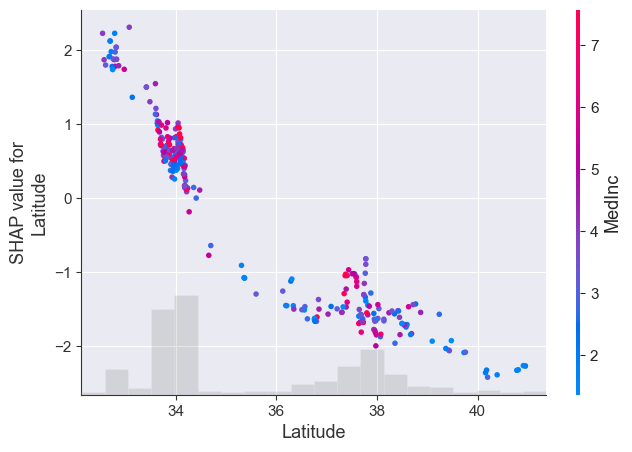

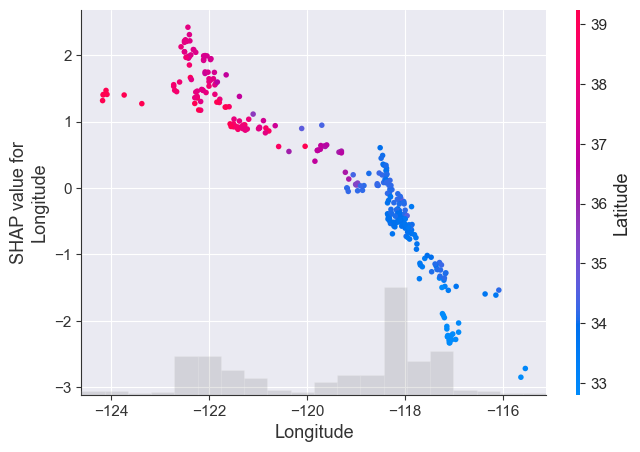

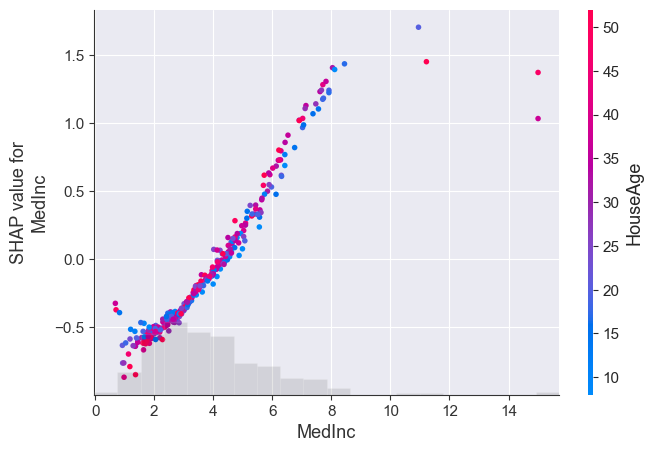

In [50]:
for feature in top_features_shap:
    shap.plots.scatter(
        best_shap_values[:, feature],
        color=best_shap_values
    )

### Interpretarea analizei SHAP pentru regresie

Analiza SHAP evidențiază caracteristicile care influențează cel mai mult predicțiile modelelor de regresie. Bar plot-ul prezintă importanța globală a caracteristicilor, calculată pe baza valorilor SHAP absolute medii. Beeswarm plot-ul arată atât importanța caracteristicilor, cât și direcția influenței acestora asupra predicției.

Waterfall plot-ul oferă o explicație locală pentru o singură predicție, indicând ce caracteristici au crescut sau au scăzut valoarea prezisă față de valoarea de bază a modelului.

Scatter plot-urile SHAP permit observarea modului în care valorile unei caracteristici influențează predicția. Valorile SHAP pozitive împing predicția în sus, iar valorile SHAP negative împing predicția în jos.

Cele mai importante 3 caracteristici sunt identificate pe baza valorii medii absolute SHAP. Acestea reprezintă variabilele care au contribuit cel mai mult la predicțiile modelelor analizate.

In [51]:
import joblib
from pathlib import Path

models_dir = PROJECT_ROOT / "models" / "regression"
tables_dir = PROJECT_ROOT / "reports" / "tables"

models_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

for model_name, model in tuned_regression_models.items():
    safe_name = model_name.lower().replace(" ", "_").replace("-", "_")
    joblib.dump(model, models_dir / f"{safe_name}.joblib")

regression_results_df.to_csv(
    tables_dir / "regression_base_results.csv",
    index=False
)

tuned_regression_results_df.to_csv(
    tables_dir / "regression_tuned_results.csv",
    index=False
)

joblib.dump(
    best_regression_params_by_model,
    tables_dir / "regression_best_params.joblib"
)

print("Modelele și rezultatele pentru regresie au fost salvate.")

Modelele și rezultatele pentru regresie au fost salvate.


## 8. Concluzii pentru problema de regresie

În cadrul problemei de regresie au fost analizate mai multe modele de machine learning, pornind de la variantele de bază și continuând cu ajustarea hiperparametrilor pentru primele 5 modele. Modelele au fost evaluate folosind metricile MSE, MAE, RMSE și R².

După etapa de tuning, cel mai bun model a fost selectat pe baza scorului R². Acest scor indică proporția variației variabilei țintă explicată de model, iar valorile mai apropiate de 1 indică o performanță mai bună.

Curbele de învățare au fost folosite pentru a analiza comportamentul modelelor în raport cu dimensiunea setului de antrenare, iar analiza SHAP a oferit o interpretare asupra caracteristicilor care influențează cel mai mult predicțiile.

Astfel, analiza de regresie nu se limitează doar la compararea numerică a modelelor, ci include și interpretarea comportamentului acestora, conform cerințelor proiectului.
